# 04 — Simulating TOA reflectance

This notebook demonstrates `SmartgSampler_Rho_toa_sym`, which computes the top-of-atmosphere reflectance $\rho_{toa}$ from a known surface $\rho_s$.

## How it works

The adjacency effect is characterised by the PSF (Point Spread Function) of the atmosphere: photons scattered sideways by aerosols arrive at the sensor from neighbouring pixels. Under the assumption that the PSF is **radially symmetric**, `SmartgSampler_Rho_toa_sym` exploits this structure:

1. It estimates the approximate radial profile of $\rho_{toa}$ from the input $\rho_s$.
2. It selects a small set of **adaptive radial sampling points** (by gradient-driven CDF inversion) — typically 50–100 points instead of the full 2D grid.
3. It runs a **single Smart-G simulation** with one sensor per radial sample point, yielding the TOA signal at each radius.
4. It reconstructs the full 2D $\rho_{toa}$ field from the radial profile via Pchip interpolation.

This reduces the number of photon transport simulations by several orders of magnitude compared to a pixel-by-pixel approach.

The underlying hypthesis is that the viewing zenith angle of the satellite (VZA) is close to nadir. In practice, the simulation remains valid for low Viewing Zenith Angles (<20°). Performances start to decrease significally over 50°. In order to perform exact simulation of the $\rho_{toa}$, please use the `SmartgSampler_Rho_toa`.

**Requires:** GPU + `SMARTG_DIR_AUXDATA`.

In [1]:
import os
import structlog
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import adjeff
from adjeff.atmosphere import AtmoConfig, GeoConfig, SpectralConfig
from adjeff.core import S2Band, disk_image_dict, gaussian_image_dict
from adjeff.modules.samplers import RhoToaSymSampler

assert "SMARTG_DIR_AUXDATA" in os.environ

structlog.configure(
    processors=[
        structlog.processors.KeyValueRenderer(key_order=["event"]),
    ],
    logger_factory=structlog.PrintLoggerFactory(file=open("/dev/null", "w")),
)

## 4.1 — Setup: surface and atmospheric state

First, we setup a single atmosphere with 3 different Sentinel-2 bands, and a Gaussian surface reflectance map with a fixed $10~m$ resolution, a standard deviation of $3.0~km$ and a $(1001, 1001)$ input size.

In [2]:
BANDS = [S2Band.B02, S2Band.B03, S2Band.B04]

# Create a Gaussian surface (bright target, dark background)
scene = disk_image_dict(
    radius=3.0,        # 300 m half-width
    res_km=0.01,      # 10 m resolution
    rho_min=0.05,
    rho_max=0.6,
    bands=BANDS,
    n=1001,
)

atmo = AtmoConfig(
    aot=xr.DataArray([0.6], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)

geo = GeoConfig(
    sza=xr.DataArray([30.0], dims=["sza"]),
    vza=xr.DataArray([0.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([0.0], dims=["vaa"]),
)

spectral = SpectralConfig.from_bands(BANDS)

## 4.2 — Run the TOA simulation

The TOA reflectance siulation can now be performed for each bands.

In [3]:
module = RhoToaSymSampler(
    atmo_config=atmo,
    geo_config=geo,
    remove_rayleigh=False,
    nr=80,           # number of radial sampling points
    n_ph=int(5e5),   # photons per sensor — increase for less noise
)

scene = module(scene)
print("Variables available after module:")
for var in scene[S2Band.B02].data_vars:
    print(f"  {var}: {list(scene[S2Band.B02][var].dims)}")

/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:1124: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : incompatible redefinition for option 'compiler-bindir', the last value of this option was used

  self.mod = SourceModule(


Box(children=(FloatProgress(value=0.0, max=90000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=58500000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=58500000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=58500000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
Variables available after module:
  rho_s: ['y', 'x']
  rho_atm: ['vza', 'sza', 'aot', 'rh', 'href', 'h']
  rho_toa: ['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x']


## 4.3 — Compare ρ_s and ρ_toa

Then, it is straighforward to compare the initial surface reflectance and the simulated TOA reflectance. 

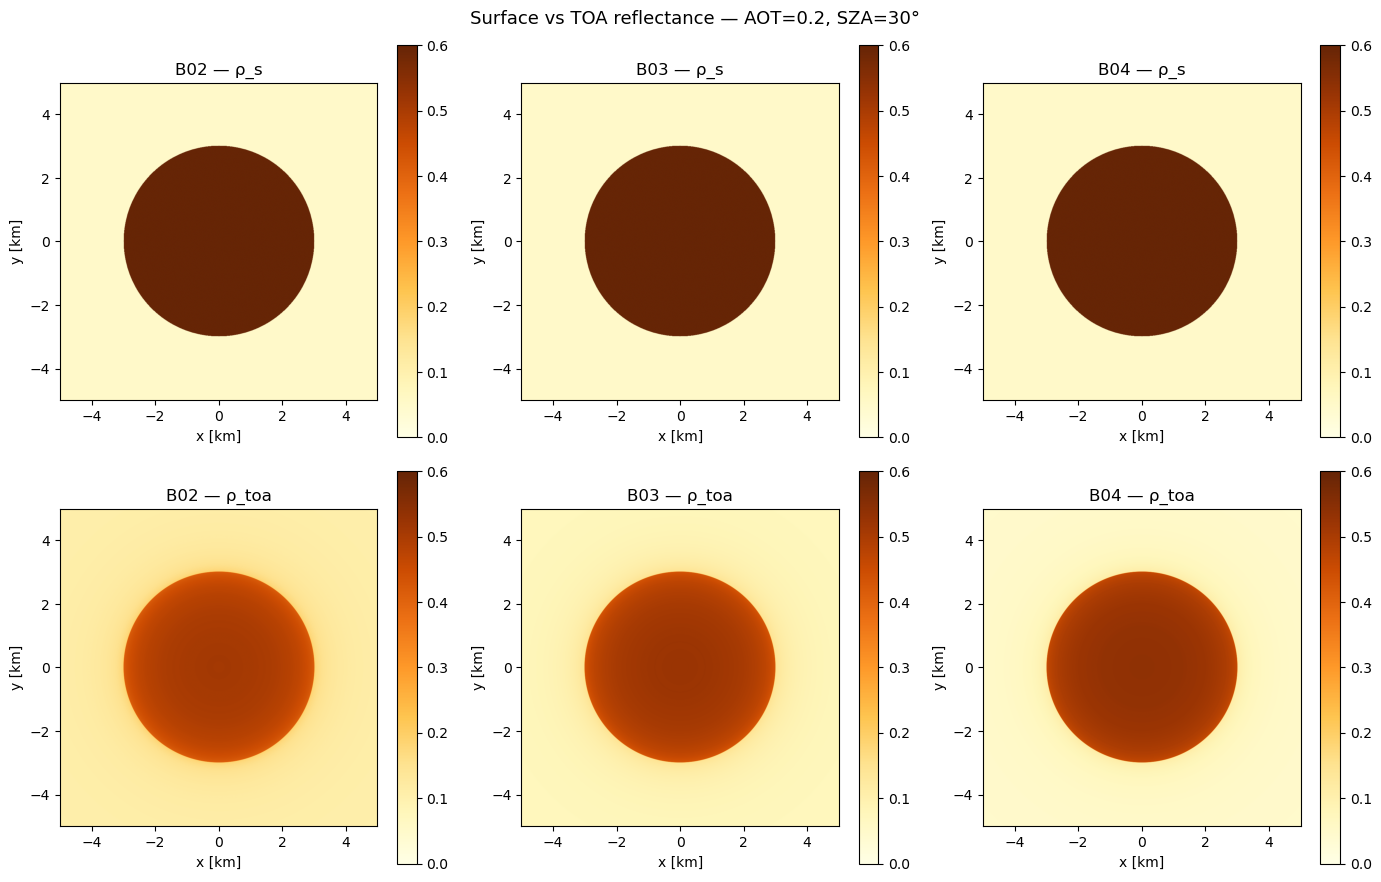

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for col, band in enumerate(BANDS):
    ds = scene[band]
    rho_s = ds["rho_s"].values
    rho_toa = ds["rho_toa"].squeeze().values

    coords = ds["rho_s"]
    extent = [
        float(coords.coords["x"].min()), float(coords.coords["x"].max()),
        float(coords.coords["y"].min()), float(coords.coords["y"].max()),
    ]
    vmax = max(rho_s.max(), rho_toa.max())

    for row, (data, title) in enumerate([(rho_s, "ρ_s"), (rho_toa, "ρ_toa")]):
        ax = axes[row, col]
        im = ax.imshow(data, origin="lower", extent=extent, vmin=0, vmax=vmax, cmap="YlOrBr")
        ax.set_title(f"{band.id} — {title}")
        ax.set_xlabel("x [km]")
        ax.set_ylabel("y [km]")
        plt.colorbar(im, ax=ax)

fig.suptitle("Surface vs TOA reflectance — AOT=0.2, SZA=30°", fontsize=13)
plt.tight_layout()
plt.show()

## 4.4 — Radial profiles: quantifying the adjacency effect

A radial view is better for direct comparison. See how the contrast of the surface reflectance is decreased on TOA reflectance. The contrast on TOA reflectance gradually increase with the wavelength, as the AOT of the sulphate specie decrease with the AOT.

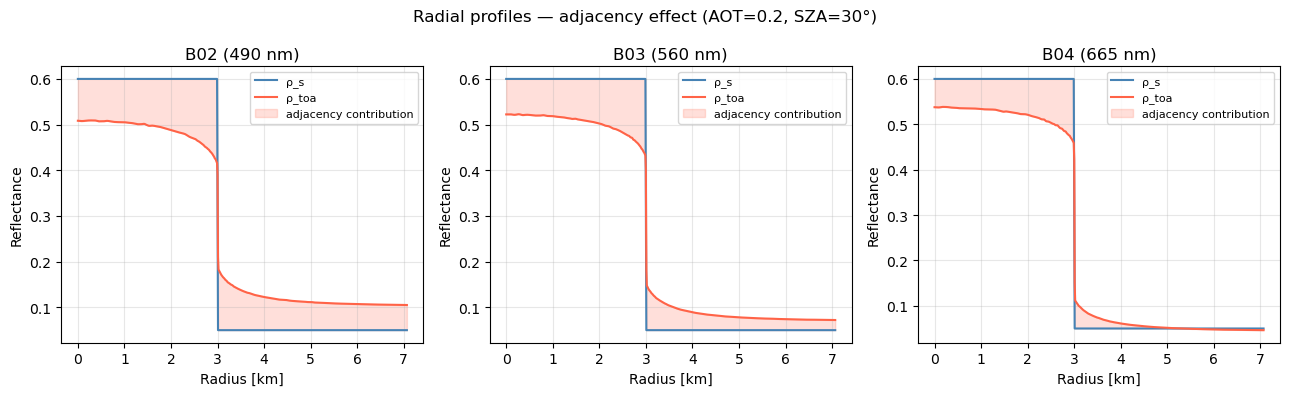

In [5]:
fig, axes = plt.subplots(1, len(BANDS), figsize=(13, 4))

for ax, band in zip(axes, BANDS):
    ds = scene[band]
    rho_s = ds["rho_s"]
    rho_toa = ds["rho_toa"].squeeze()

    profile_s = rho_s.adjeff.radial()
    profile_toa = rho_toa.adjeff.radial()

    ax.plot(profile_s.coords["r"], profile_s.values, label="ρ_s", color="steelblue")
    ax.plot(profile_toa.coords["r"], profile_toa.values, label="ρ_toa", color="tomato")
    ax.fill_between(
        profile_s.coords["r"],
        profile_s.values,
        profile_toa.values,
        alpha=0.2, color="tomato", label="adjacency contribution",
    )
    ax.set_title(f"{band.id} ({band.wl_nm:.0f} nm)")
    ax.set_xlabel("Radius [km]")
    ax.set_ylabel("Reflectance")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Radial profiles — adjacency effect (AOT=0.2, SZA=30°)", fontsize=12)
plt.tight_layout()
plt.show()

## 4.5 — Effect of AOT on the adjacency contribution

Effects of the AOT on the TOA reflectance can be simply studied with the following configuration. See how the contrast gradually decrease with the AOT.

/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/luts/luts.py:596: RuntimeWarning: invalid value encountered in divide
  return self.__binary_operation__(other, lambda x, y: x/y)
/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:3350: RuntimeWarning: invalid value encountered in divide
  scum /= scum[-1]
/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:3403: RuntimeWarning: invalid value encountered in divide
  scum /= scum[-1]


Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/luts/luts.py:596: RuntimeWarning: invalid value encountered in divide
  return self.__binary_operation__(other, lambda x, y: x/y)
/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:3350: RuntimeWarning: invalid value encountered in divide
  scum /= scum[-1]
/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:3403: RuntimeWarning: invalid value encountered in divide
  scum /= scum[-1]


Box(children=(FloatProgress(value=0.0, max=58500000.0), Label(value='')), layout=Layout(align_items='center', …

...

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=58500000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


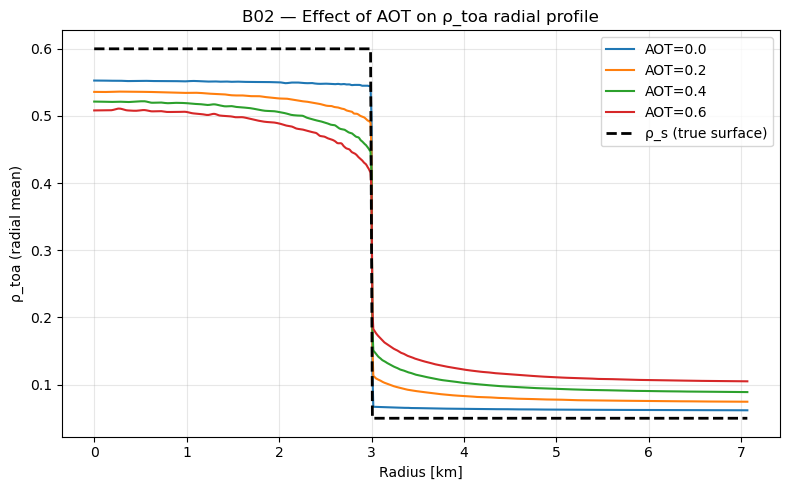

In [6]:
aot_test = [0.0, 0.20, 0.40, 0.60]
fig, ax = plt.subplots(figsize=(8, 5))

for aot_val in aot_test:
    atmo_test = AtmoConfig(
        aot=xr.DataArray([aot_val], dims=["aot"]),
        h=xr.DataArray([0.0], dims=["h"]),
        rh=xr.DataArray([50.0], dims=["rh"]),
        href=xr.DataArray([2.0], dims=["href"]),
        species={"sulphate": 1.0},
    )
    mod_test = RhoToaSymSampler(
        atmo_config=atmo_test,
        geo_config=geo,
        remove_rayleigh=False,
        nr=80,
        n_ph=int(5e5),
    )
    scene_test = disk_image_dict(
        radius=3.0, res_km=0.01, rho_min=0.05, rho_max=0.6,
        bands=[S2Band.B02], n=1001,
    )
    scene_test = mod_test(scene_test)
    rho_toa = scene_test[S2Band.B02]["rho_toa"].squeeze()
    profile = rho_toa.adjeff.radial()
    ax.plot(profile.coords["r"], profile.values, label=f"AOT={aot_val}")

# Reference surface profile
rho_s_ref = disk_image_dict(
    radius=3.0, res_km=0.01, rho_min=0.05, rho_max=0.6,
    bands=[S2Band.B02], n=1001,
)[S2Band.B02]["rho_s"]
profile_s = rho_s_ref.adjeff.radial()
ax.plot(
    profile_s.coords["r"], 
    profile_s.values, 
    "k--", 
    label="ρ_s (true surface)", 
    linewidth=2,
)

ax.set_xlabel("Radius [km]")
ax.set_ylabel("ρ_toa (radial mean)")
ax.set_title("B02 — Effect of AOT on ρ_toa radial profile")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.6 — 2D simulation: SmartgSampler_Rho_toa

`SmartgSampler_Rho_toa` lifts the radial symmetry assumption of the `_sym` variant. Instead of collapsing the scene to a 1D radial profile, it places `nx × ny` Smart-G sensors on an explicit pixel sub-grid and passes the full 2D reflectance map to Smart-G via an `Albedo_map` environment.

Key differences from `SmartgSampler_Rho_toa_sym`:
- Requires an **arbitrary** surface map (`analytical=False`); `SmartgSampler_Rho_toa_sym` raises a `ValueError` if an arbitrary field is passed.
- Sensors cover a rectangular sub-grid defined by `topleft_pix`, `nx`, `ny`; pixels outside are set to `NaN`.
- A companion boolean variable `rho_toa_valid` marks which pixels were computed.
- Valid at **any VZA**, including large viewing angles where the PSF is no longer circular.
- `rho_background` controls the `LambSurface` albedo used by Smart-G for photons that leave the `Albedo_map` region (`"mean"`, `"min"`, `"zero"`, or an explicit float — default `"mean"`).

In [7]:
from adjeff.modules.samplers import RhoToaSampler

BAND_2D = S2Band.B02

atmo_2d = AtmoConfig(
    aot=xr.DataArray([0.4], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)
geo_2d = GeoConfig(
    sza=xr.DataArray([30.0], dims=["sza"]),
    vza=xr.DataArray([0.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([0.0], dims=["vaa"]),
)

# analytical=False required by RhoToaSampler
scene_2d = gaussian_image_dict(
    sigma=5.0, res_km=0.5, rho_min=0.05, rho_max=0.6,
    bands=[BAND_2D], n=51, analytical=False,
)

sampler_2d = RhoToaSampler(
    atmo_config=atmo_2d,
    geo_config=geo_2d,
    remove_rayleigh=False,
    nx=51, ny=51,
    topleft_pix=(0, 0),
    n_ph=int(1e4),
    n_alb=10,
)
scene_2d = sampler_2d(scene_2d)

print("Variables in the 2D scene:")
for var in scene_2d[BAND_2D].data_vars:
    print(f"  {var}: {list(scene_2d[BAND_2D][var].dims)}")

Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=26010000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
Variables in the 2D scene:
  rho_s: ['y', 'x']
  rho_atm: ['vza', 'sza', 'aot', 'rh', 'href', 'h']
  rho_toa: ['vza', 'sza', 'y', 'x', 'aot', 'rh', 'href', 'h']
  rho_toa_valid: ['y', 'x']


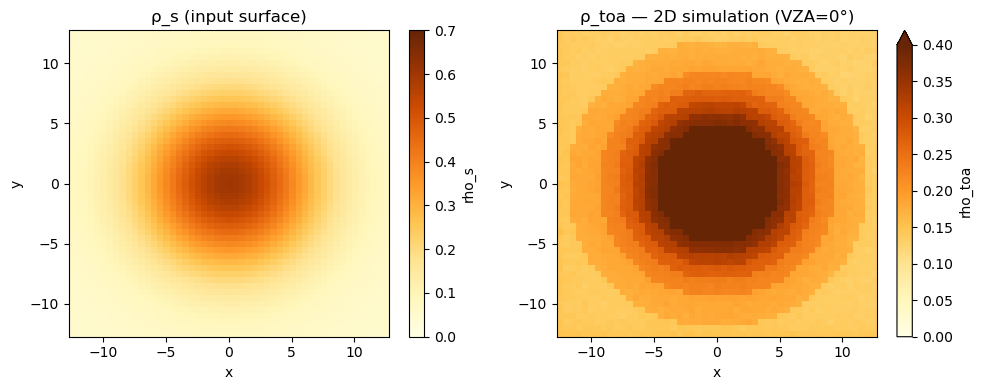

In [8]:
ds = scene_2d[BAND_2D]
rho_s_2d   = ds["rho_s"]
rho_toa_2d = ds["rho_toa"].squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rho_s_2d.plot.imshow(ax=axes[0], cmap="YlOrBr", vmin=0.0, vmax=0.7)
axes[0].set_title("ρ_s (input surface)")
rho_toa_2d.plot.imshow(ax=axes[1], cmap="YlOrBr", vmin=0.0, vmax=0.4)
axes[1].set_title("ρ_toa — 2D simulation (VZA=0°)")
plt.tight_layout()
plt.show()

## 4.7 — Sym vs 2D: 2D error maps at VZA=0° and VZA=60°

At nadir (VZA=0°) the atmospheric PSF is radially symmetric, so `SmartgSampler_Rho_toa_sym` and `SmartgSampler_Rho_toa` should agree nearly everywhere — residuals reflect only Monte Carlo noise.

At VZA=60° the PSF elongates along the viewing direction. `SmartgSampler_Rho_toa_sym` still forces a circular profile, causing systematic spatial biases visible in the relative error map `(ρ_sym − ρ_2D) / ρ_2D`.

Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=100000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

...

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=26010000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


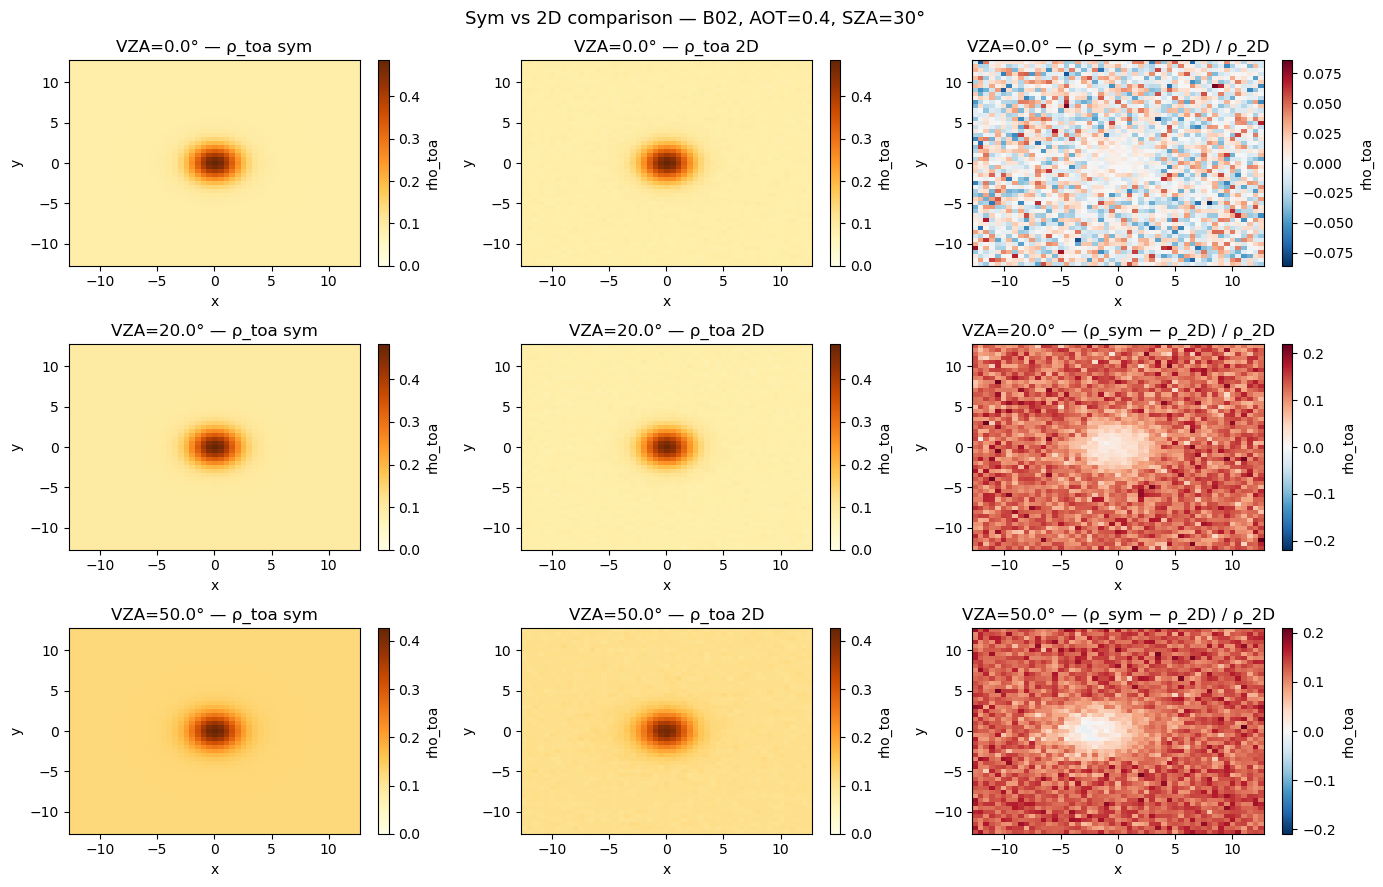

In [9]:
VZA_VALUES = [0.0, 20.0, 50.0]
N_COMPARE = 51
SIGMA_COMPARE = 1.5

results = {}

for vza_val in VZA_VALUES:
    geo_v = GeoConfig(
        sza=xr.DataArray([30.0], dims=["sza"]),
        vza=xr.DataArray([vza_val], dims=["vza"]),
        saa=xr.DataArray([120.0], dims=["saa"]),
        vaa=xr.DataArray([0.0], dims=["vaa"]),
    )

    scene_sym = gaussian_image_dict(
        sigma=SIGMA_COMPARE, res_km=0.5, rho_min=0.0, rho_max=0.6,
        bands=[BAND_2D], n=N_COMPARE, analytical=True
    )
    sampler_sym_v = RhoToaSymSampler(
        atmo_config=atmo_2d, geo_config=geo_v,
        remove_rayleigh=False, nr=50, n_ph=int(5e5),
    )
    scene_sym = sampler_sym_v(scene_sym)

    scene_2d_v = gaussian_image_dict(
        sigma=SIGMA_COMPARE, res_km=0.5, rho_min=0.0, rho_max=0.6,
        bands=[BAND_2D], n=N_COMPARE, analytical=False,
    )
    sampler_2d_v = RhoToaSampler(
        atmo_config=atmo_2d, geo_config=geo_v,
        remove_rayleigh=False, nx=N_COMPARE, ny=N_COMPARE,
        topleft_pix=(0, 0), n_ph=int(1e4), n_alb=1000,
        rho_background="min"
    )
    scene_2d_v = sampler_2d_v(scene_2d_v)

    rho_sym = scene_sym[BAND_2D]["rho_toa"].squeeze()
    rho_2d  = scene_2d_v[BAND_2D]["rho_toa"].squeeze()
    rel_err = (rho_sym - rho_2d) / rho_2d
    results[vza_val] = (rho_sym, rho_2d, rel_err)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
col_titles = ["ρ_toa sym", "ρ_toa 2D", "(ρ_sym − ρ_2D) / ρ_2D"]

for row, vza_val in enumerate(VZA_VALUES):
    rho_sym, rho_2d, rel_err = results[vza_val]
    vmax = float(max(rho_sym.max(), rho_2d.max()))
    err_abs = float(abs(rel_err).max())

    for col, (data, cmap, vmin_c, vmax_c) in enumerate([
        (rho_sym, "YlOrBr", 0.0, vmax),
        (rho_2d,  "YlOrBr", 0.0, vmax),
        (rel_err, "RdBu_r", -err_abs, err_abs),
    ]):
        ax = axes[row, col]
        img = data.plot.imshow(ax=ax, cmap=cmap, vmin=vmin_c, vmax=vmax_c, add_colorbar=True)
        ax.set_title(f"VZA={vza_val}° — {col_titles[col]}")

fig.suptitle(
    f"Sym vs 2D comparison — {BAND_2D.id}, AOT=0.4, SZA=30°", fontsize=13
)
plt.tight_layout()
plt.show()

## 4.8 — Transect profiles: Sym vs 2D along vaa and perpendicular axes

A transect through the scene centre reveals the asymmetry of the adjacency
effect more directly than a radial average.

- **Along vaa (angle = VAA°)**: shows the elongated axis of the PSF.  At
  large VZA, `rho_2D` is wider than `rho_sym` here because `rho_sym` was
  built from sensors placed on the *perpendicular* (narrow) axis.
- **Along ⊥ vaa (angle = VAA + 90°)**: the PSF width matches by construction
  (sym sensors sit on this axis), so the two curves should overlap closely.

If both transects overlap, the PSF is radially symmetric at this VZA.  If
the vaa transect diverges while the perp one does not, the PSF is elongated.

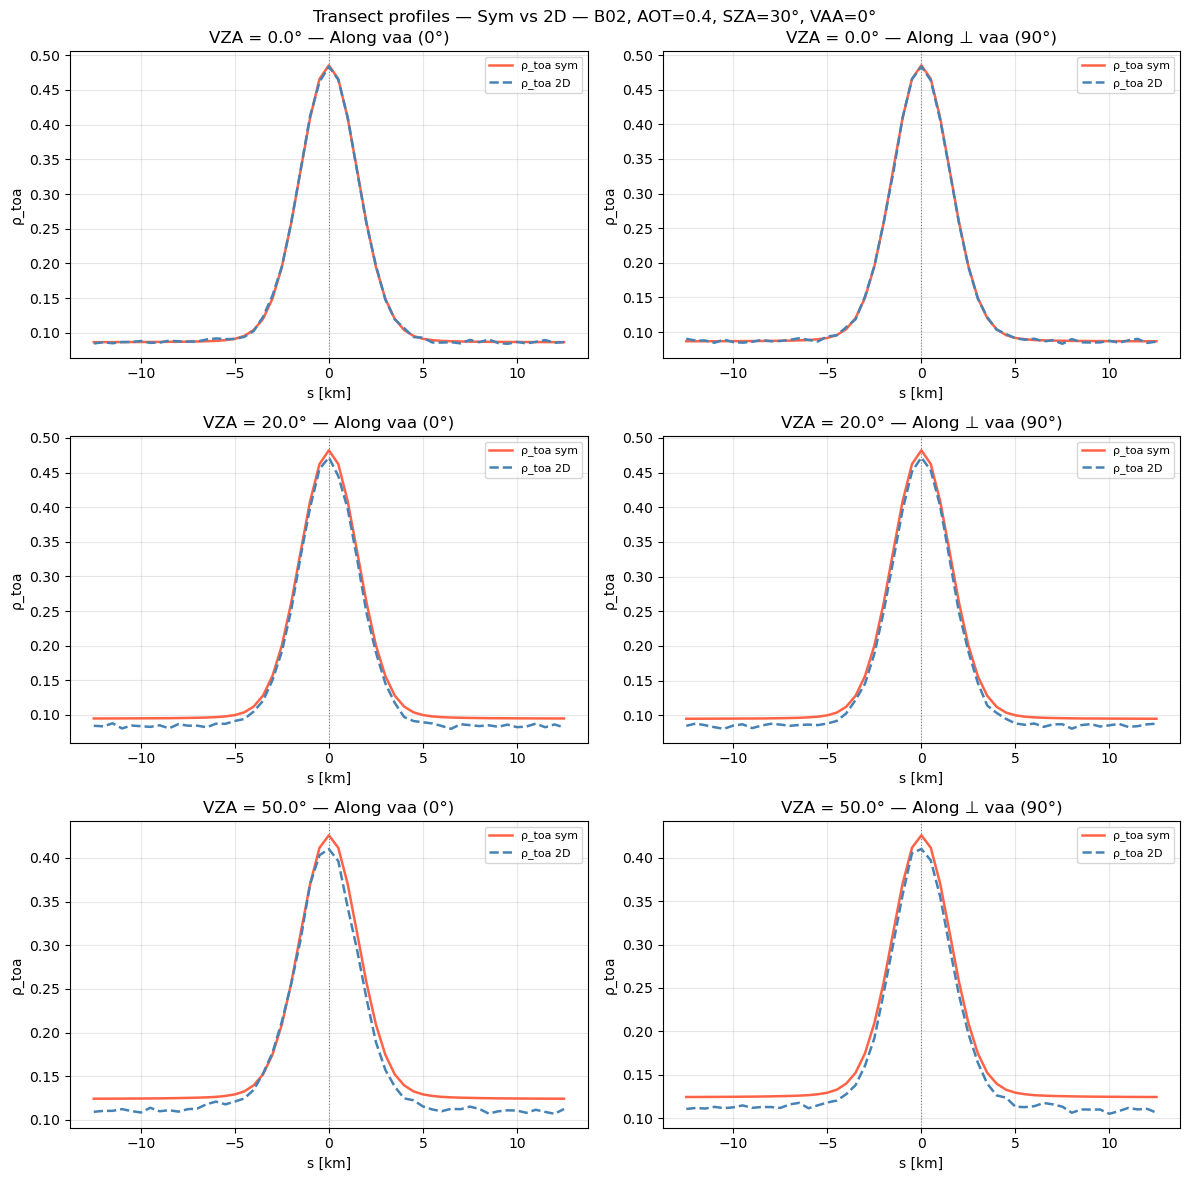

In [10]:
VAA_DEG = 0.0  # viewing azimuth used in the comparison loop above
PERP_DEG = VAA_DEG + 90.0

fig, axes = plt.subplots(
    len(VZA_VALUES), 2,
    figsize=(12, 4 * len(VZA_VALUES)),
    sharey=False,
)
col_titles = [
    f"Along vaa ({VAA_DEG:.0f}°)",
    f"Along ⊥ vaa ({PERP_DEG:.0f}°)",
]

for row, vza_val in enumerate(VZA_VALUES):
    rho_sym, rho_2d, _ = results[vza_val]

    for col, angle in enumerate([VAA_DEG, PERP_DEG]):
        ax = axes[row, col]
        t_sym = rho_sym.adjeff.transect(angle)
        t_2d  = rho_2d.adjeff.transect(angle)

        ax.plot(t_sym.coords["s"], t_sym.values,
                label="ρ_toa sym", color="tomato", linewidth=1.8)
        ax.plot(t_2d.coords["s"], t_2d.values,
                label="ρ_toa 2D", color="steelblue",
                linestyle="--", linewidth=1.8)
        ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
        ax.set_title(f"VZA = {vza_val}° — {col_titles[col]}")
        ax.set_xlabel("s [km]")
        ax.set_ylabel("ρ_toa")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Transect profiles — Sym vs 2D — {BAND_2D.id}, "
    f"AOT=0.4, SZA=30°, VAA={VAA_DEG:.0f}°",
    fontsize=12,
)
plt.tight_layout()
plt.show()